# 🤓📊 Statistical Testing for Dummies
> **Author:** Shi Long Hong Zhuang

> **Date Published:** Nov 23, 2022

**Inspiration**:

   - A very friendly guide about statistical testing made dummy-friendly for beginner to intermediate level data scientists and data analysts alike.  
   - Information is provided in bullet points rather than long paragraphs for easier reading and retention
   - Diagrams and charts are presented to visually understand the logic behind the workflows

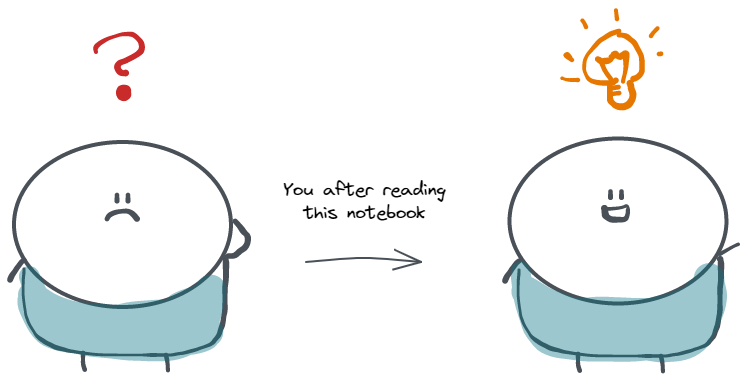

# Table of Contents

0. Key terminologies 
2. When to perform a statistical test
3. Parametric tests: regression, comparison, or correlation tests
4. Nonparametric tests
5. Sample Codes

# Key Terminologies

**Dependent and Independent Variables**

From the world itself, a dependent variable is dependent/based on the independent variable.
- Independent variable is also called predictor variable
- Dependent variable is also called output variable


**Types of Variables**

It is critical to determine the type of variables that are being tested to know the appropriate statistical test to adopt. It is mainly divided into 2 main categories and further subdivided as follows:

1. **Numerical:** expressed in terms of numbers
    - **Discrete:** describe counts, can only be expressed in whole numbers
    - **Continuous:** describe measures, can be expressed with decimal points
    
    
2. **Categorical:** expressed in terms of groupings
    - **Ordinal:** represent data with an order
    - **Nominal:** represent data in group names
   
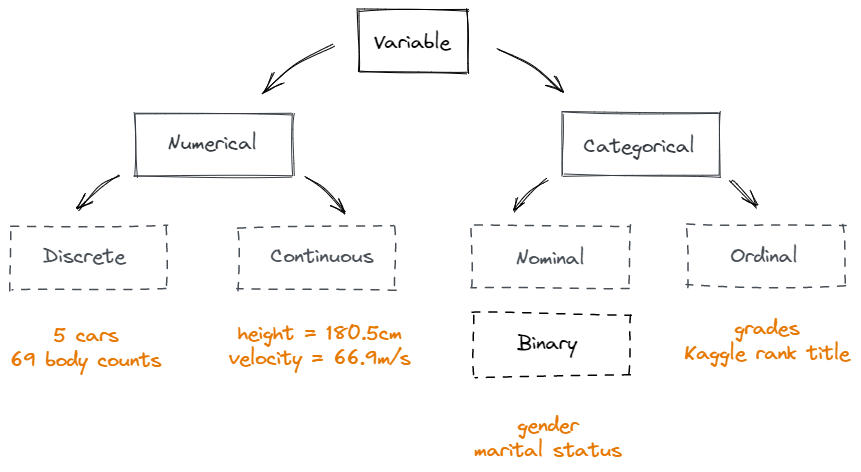

# Statistical Tests

- Statistics allows us to interpret our data
- Statistical tests enable us to investigate the effect and relationship between the variables we are testing on.

**Hypothesis Testing**
- Statistical tests are used in Hypothesis testing.
    - to determine if the variables are significantly related with one another
    - assess the difference between the groups in comparison
    
    
- This test assumes a null hypothesis of no difference/relationship between groups, which will then be validated by performing **stats test** and determining if there is **enough evidence** to suggest that the null hypothesis is true.

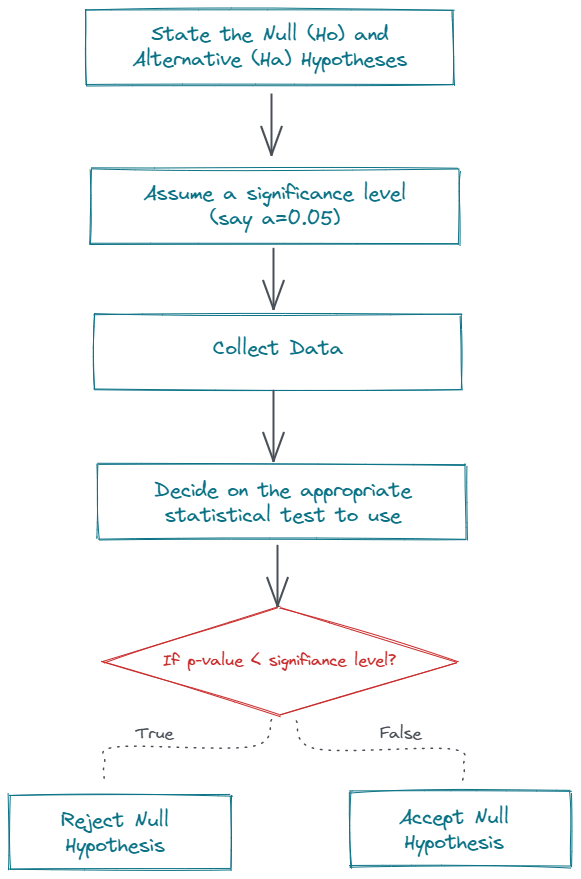

# Choosing a Parametric Test
The most common types of parametric tests include regresion, comparison, and correlation tests:

1. **Regression tests**
    - seeks to explain the cause-and-effect relationship between variables.
    - only applies on **continuous or binary data.**
    
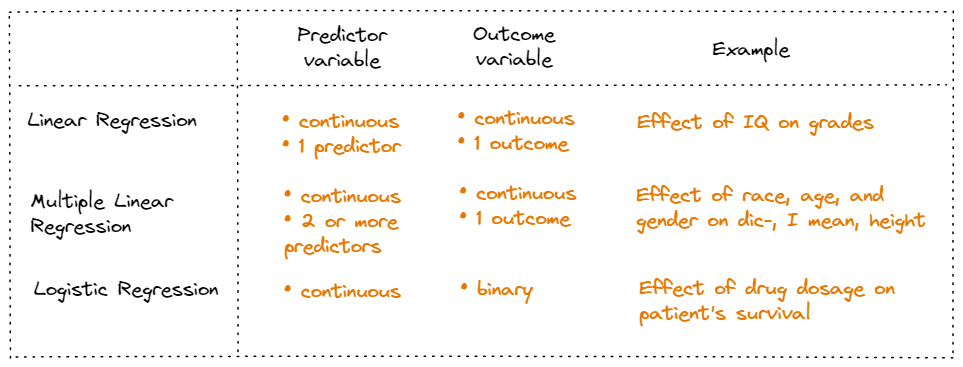

2. **Comparison tests**
    - asseses the difference of means among groups, the means (average) become the metric that is being compared here.
    - **t-tests** for comparing means of two groups
    - **ANOVA** test when comparing means of 2+ groups
    
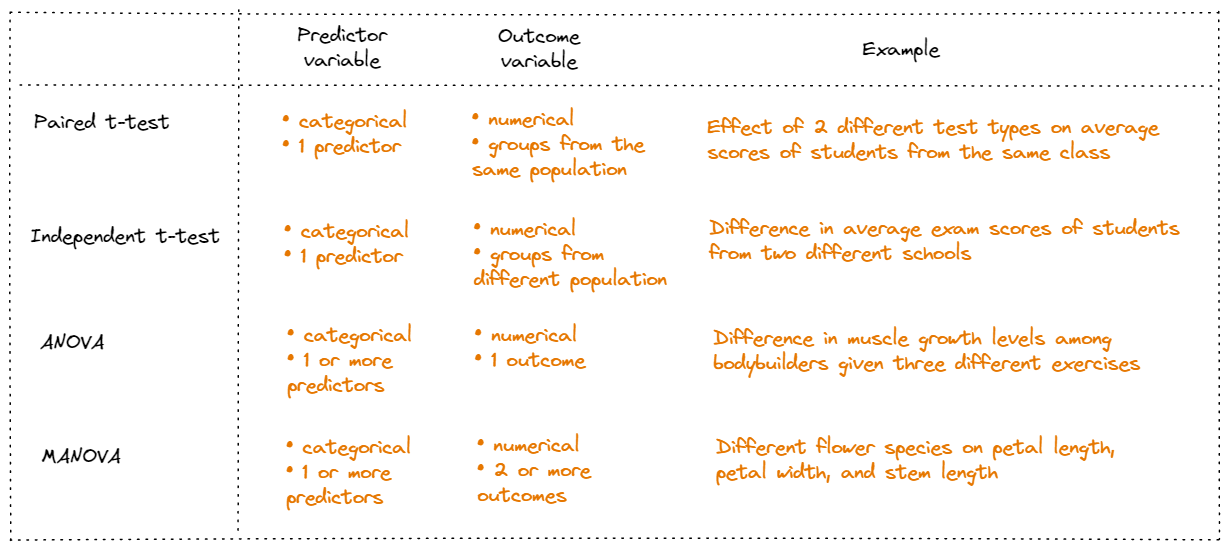

3. **Correlation tests**
    - test how variables are related with one another without the need to perform regression analysis
    
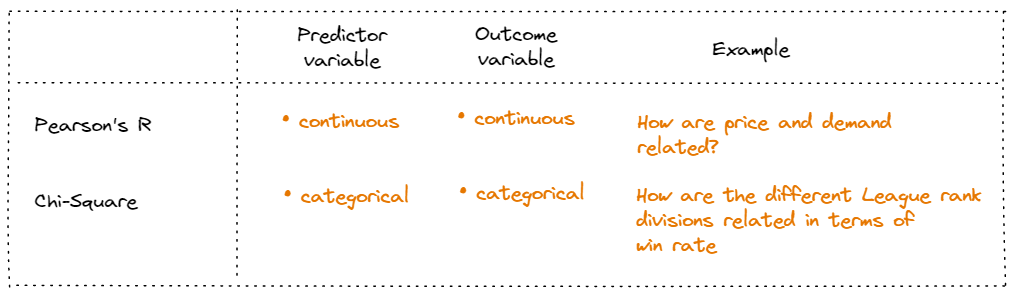

# Choosing a Nonparametric Test

Non-parametric tests are used when one or more statistical assumptions are violated. It must be noted that these tests' inferences are usually not as strong as with parametric tests.

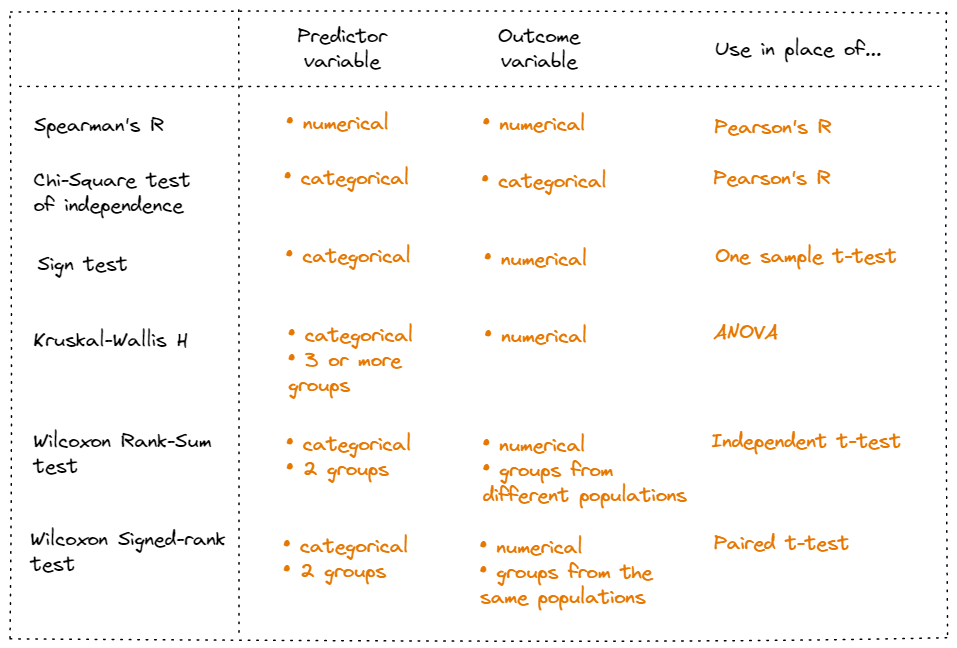

# Cheat Sheet: Choosing the Statistical Test

This flowchart can definitely help for a dummy like me. 

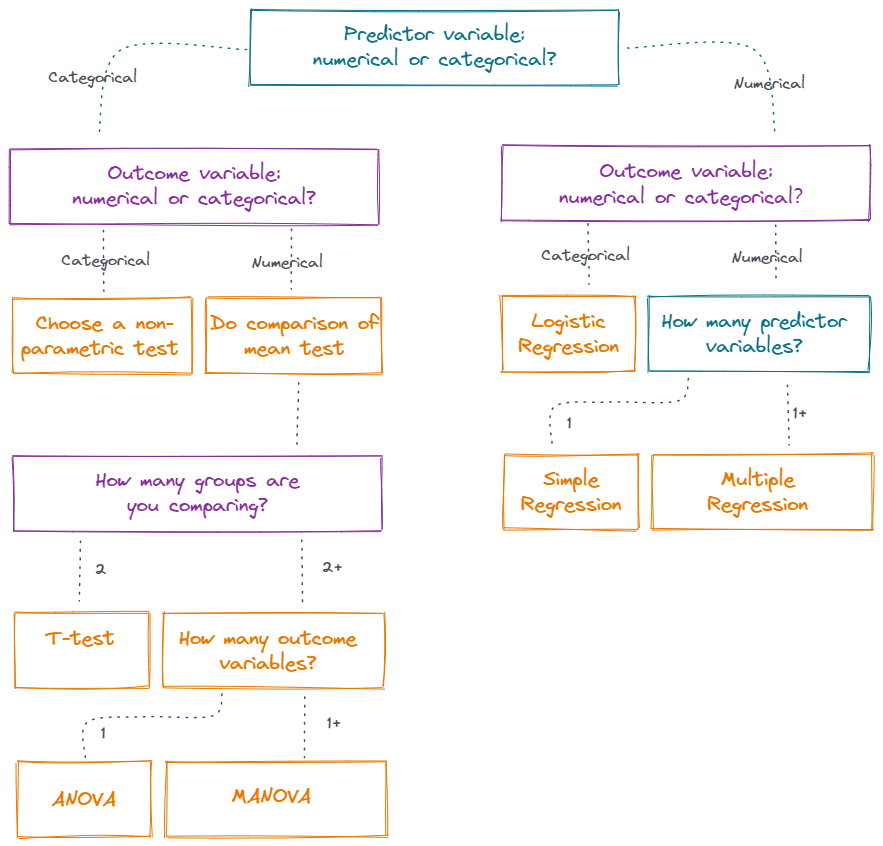

# Sample Codes

**Comparison test**

*Independent t-test*
- Look for the difference in the number of goals between the Home and Away teams of World Cup soccer matches
- **predictor variable:** Home and Away teams
- **output variable:** goals

In [ ]:
import pandas as pd
wcm = pd.read_csv('/kaggle/input/soccer-world-cup-challenge/world_cup_matches.csv')
wcm[['Home Goals', 'Away Goals']].head()

In [ ]:
from scipy.stats import ttest_ind
# Convert dataframe column to lists of data
stat, p = ttest_ind( wcm['Home Goals'].tolist(), wcm['Away Goals'].tolist() )
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Accept the Null Hypothesis. There is no significant difference between the groups.')
else:
	print('Accept the Alternative Hypothesis. There is a significant difference between the groups.')

---
**Comparison test**

*ANOVA*
- Test whether the revenue contributed from different payment method used by customers are any significantly different. 
- **predictor variables:** payment method (credit card, bank withdrawal, etc.)
- **output variable:** total revenue

In [ ]:
churn = pd.read_csv('/kaggle/input/telecom-customer-churn-by-maven-analytics/telecom_customer_churn.csv')
churn.head()

In [ ]:
# Filtering the lists of data for each payment method
cc = churn[churn['Payment Method'] == 'Credit Card']['Total Revenue'].to_list()
bw = churn[churn['Payment Method'] == 'Bank Withdrawal']['Total Revenue'].to_list()
mc = churn[churn['Payment Method'] == 'Mailed Check']['Total Revenue'].to_list()

In [ ]:
# Example of the Analysis of Variance Test
from scipy.stats import f_oneway

stat, p = f_oneway(cc, bw, mc)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Accept the Null Hypothesis. There is no significant difference among the groups.')
else:
	print('Accept the Alternative Hypothesis. There is a significant difference among the groups.')

---
**Correlation Test**

*Pearson's Correlation Test*
- **predictor variable:** Lot Area
- **output variable:** House Price

In [ ]:
house_prices = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
house_prices.head()

In [ ]:
# Filtering out data in forms of lists
la = house_prices.LotArea.tolist()
sp = house_prices.SalePrice.tolist()

In [ ]:
# Example of the Pearson's Correlation test
from scipy.stats import pearsonr

stat, p = pearsonr(la, sp)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Accept the Null Hypothesis. There is no significant correlation between the variables.')
else:
	print('Accept the Alternative Hypothesis. There is a significant correlation between the variables.')

---
**Correlation Test**

*Chi-Squared Test*
- **predictor variable:** gender
- **output variable:** survival passengers

In [ ]:
titanic = pd.read_csv('/kaggle/input/titanic/train.csv')
titanic.head()

In [ ]:
# Create a matrix between the predictor and output variables
titanic.groupby('Survived')['Sex'].value_counts().unstack()

In [ ]:
# Example of the Chi-Squared Test
from scipy.stats import chi2_contingency
table = [[81, 468],[233, 109]]
stat, p, dof, expected = chi2_contingency(table)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Accept the Null Hypothesis. There is no significant difference between the groups.')
else:
	print('Accept the Alternative Hypothesis. There is a significant difference between the groups.')

---
**BONUS**
- Let me prep u up real quick
- There is another form of statistical test that is commonly used in time series analysis
- We use **Stationary tests** to check if a time series is stationary (follows no trend and constant variance) or not. 

**Stationary Tests**

*Augmented Dickey-Fuller Unit Root Test*





In [ ]:
pizza = pd.read_excel('/kaggle/input/pizza-sales/Data Model - Pizza Sales.xlsx')
sales = pizza[['order_date', 'quantity']]
sales.head()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Convert to datetime format
sales = sales.groupby(['order_date'])['quantity'].sum().reset_index()
sales['order_date'] = pd.to_datetime(sales['order_date'])

# syntax for Dickey-Fuller Test
stat, p, lags, obs, crit, t = adfuller(sales['quantity'])
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Accept the Null Hypothesis. The time series is not stationary.')
else:
	print('Accept the Alternative Hypothesis. The time series is stationary.')

In [ ]:
esales = pd.read_csv('/kaggle/input/-women-clothing-ecommerce-sales-data/women_clothing_ecommerce_sales.csv')
esales.head()

In [ ]:
esales['date'] = pd.to_datetime(esales['order_date']).dt.date

# Fill missing dates with 0 sales
idx = pd.date_range('2022-06-01', '2022-09-30')
s = esales.groupby('date')['quantity'].sum()
s.index = pd.DatetimeIndex(s.index)
s = s.reindex(idx, fill_value=0)
s = s.tolist()

In [ ]:
# syntax for Dickey-Fuller Test
stat, p, lags, abs, crit, t = adfuller(s)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Accept the Null Hypothesis. The time series is not stationary.')
else:
	print('Accept the Alternative Hypothesis. The time series is stationary.')